# Time Series EDA

This notebook is meant to be the easiest place to understand the data before training models.

## What we will inspect

- Raw schema and sample rows
- Missing values
- Overall sales trend
- State-wise sales patterns
- Weekly seasonality clues

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import clean_sales_data, load_sales_data, resample_weekly_sales
from src.utils import RAW_DATA_PATH, PROCESSED_DATA_PATH

sns.set_theme(style='whitegrid')

In [2]:
raw_df = load_sales_data(RAW_DATA_PATH)
clean_df = clean_sales_data(raw_df)
weekly_df = resample_weekly_sales(clean_df)

display(raw_df.head())
display(weekly_df.head())
print('Shape:', weekly_df.shape)
print('States:', weekly_df['State'].nunique())
print('Date range:', weekly_df['Date'].min(), 'to', weekly_df['Date'].max())

,State,Date,Total,Category
0,Alabama,1/12/2019,"109,574,036",Beverages
1,Arizona,1/12/2019,"109,101,595",Beverages
2,Arkansas,1/12/2019,"58,049,432",Beverages
3,California,1/12/2019,"444,766,891",Beverages
4,Colorado,1/12/2019,"89,816,716",Beverages


,Date,sales,State,Category
0,2019-01-13,1.095740e+08,Alabama,Beverages
1,2019-01-20,1.098646e+08,Alabama,Beverages
2,2019-01-27,1.101552e+08,Alabama,Beverages
3,2019-02-03,1.104457e+08,Alabama,Beverages
4,2019-02-10,1.107363e+08,Alabama,Beverages


Shape: (11008, 4)
States: 43
Date range: 2019-01-13 00:00:00 to 2023-12-03 00:00:00


## Missing value analysis

In [3]:
weekly_df.isna().sum()

Date        0
sales       0
State       0
Category    0
dtype: int64

## Overall trend

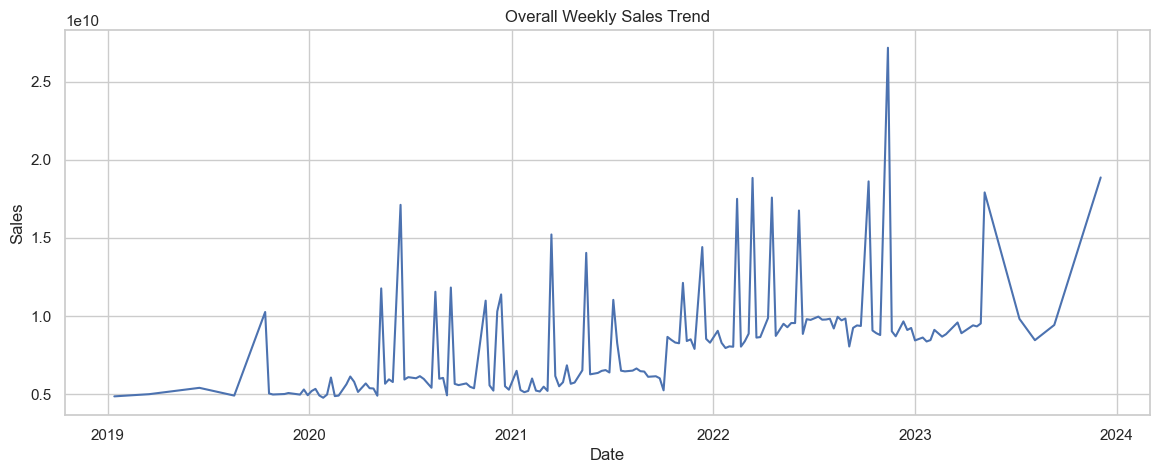

In [4]:
overall_trend = weekly_df.groupby('Date', as_index=False)['sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(overall_trend['Date'], overall_trend['sales'])
plt.title('Overall Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

## State-wise sales visualization

C:\Users\vk133\AppData\Local\Temp\ipykernel_34144\1583954550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x='sales', y='State', palette='Blues_r')


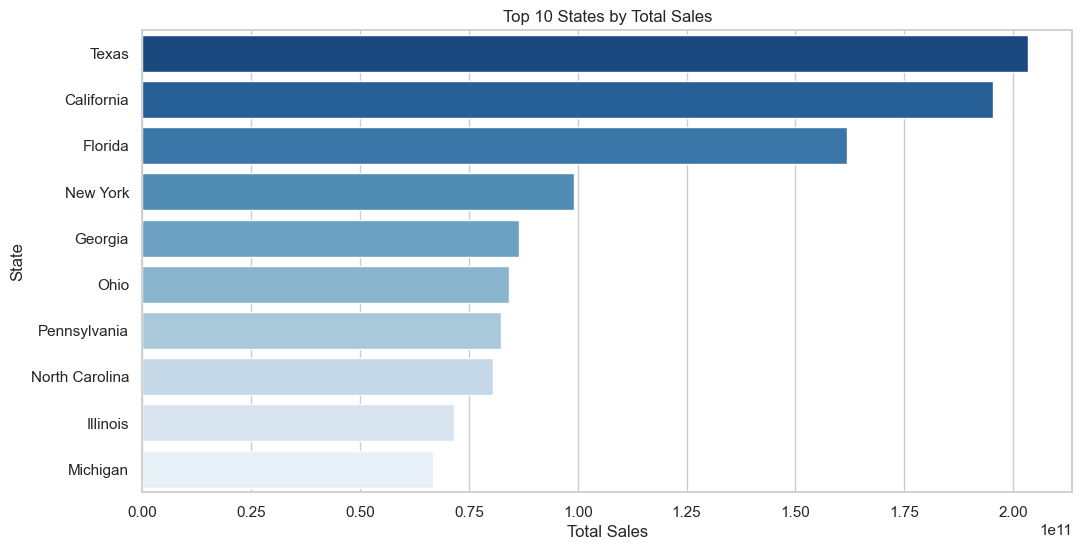

In [5]:
top_states = (
    weekly_df.groupby('State', as_index=False)['sales']
    .sum()
    .sort_values('sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='sales', y='State', palette='Blues_r')
plt.title('Top 10 States by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.show()

## Seasonality analysis

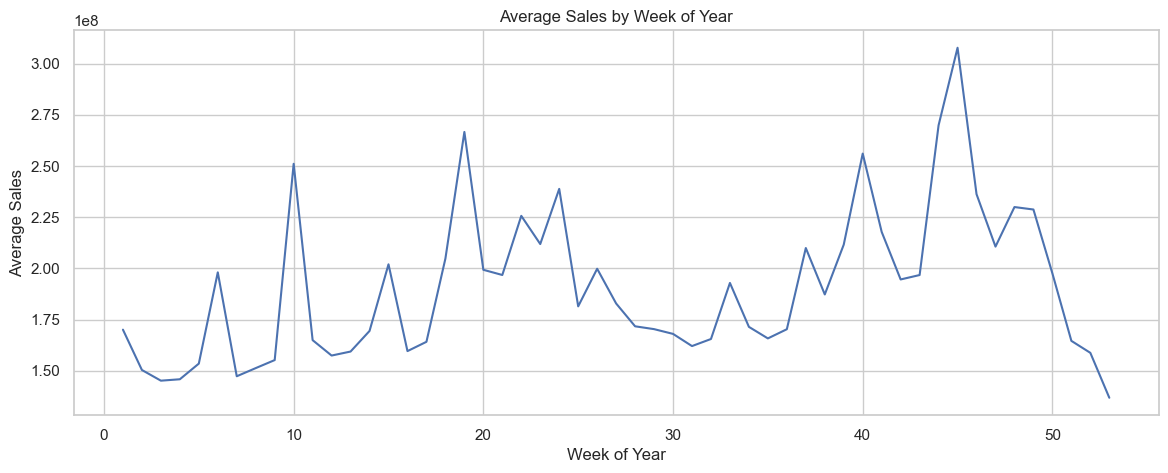

In [6]:
seasonality = weekly_df.copy()
seasonality['week_of_year'] = seasonality['Date'].dt.isocalendar().week.astype(int)
seasonality_pattern = seasonality.groupby('week_of_year', as_index=False)['sales'].mean()

plt.figure(figsize=(14, 5))
plt.plot(seasonality_pattern['week_of_year'], seasonality_pattern['sales'])
plt.title('Average Sales by Week of Year')
plt.xlabel('Week of Year')
plt.ylabel('Average Sales')
plt.show()

## One-state trend example

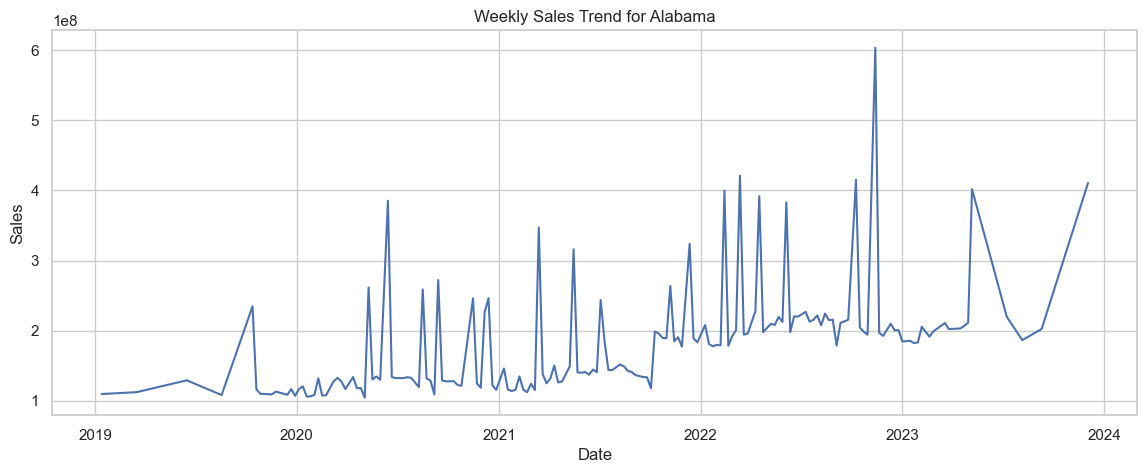

In [7]:
example_state = 'Alabama'
state_df = weekly_df[weekly_df['State'] == example_state]

plt.figure(figsize=(14, 5))
plt.plot(state_df['Date'], state_df['sales'])
plt.title(f'Weekly Sales Trend for {example_state}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()